In [1]:
import pandas as pd 


In [2]:
df1 = pd.read_excel(r"C:\Users\mocim\OneDrive\Desktop\Lessons\Week 3\Project\Mitjanes_FG_i_FE_PAU_2021-2024.xlsx")

# Link: https://universitats.gencat.cat/es/altres_pagines/informe_i_estadistiques/informe_i_estad_pau/index.html

df1.head(15)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Notes de la fase general (FG) de la PAU dels a...,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,PAU ordinària 2024 al 2021,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,La informació es facilita amb els centres anon...,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,* A les dades de la delegació territorial Terr...,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,Nota mitjana de les matèries de la Fase General,NaN,NaN,NaN
8,NaN,SERVEI_TERRITORIAL,Codi Anònim,TIPUS_CENTRE_ESTUDI *,2023/2024,2022/2023,2021/2022,2020/2021
9,NaN,Alt Pirineu i Aran,37875315,Públic,5.517,5.672,6.715,6.494


In [3]:
df1.shape

(754, 8)

In [4]:
df1.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')

In [5]:
df1 = df1.drop("Unnamed: 0", axis= 1)


In [6]:
df1.columns = ['Region', 'Anonimous_Code', 'School_type', 'Average_grade_2023/2024', 'Average_grade_2022/2023',
       'Average_grade_2021/2022', 'Average_grade_2020/2021']

In [7]:
df1 = df1.drop(df1.index[0:9])


In [8]:
df1 = df1.reset_index(drop=True)  # dropt= True removes the old index column 
df1.head()

,Region,Anonimous_Code,School_type,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
0,Alt Pirineu i Aran,37875315,Públic,5.517,5.672,6.715,6.494
1,Alt Pirineu i Aran,55689276,Públic,7.048,6.419,7.406,7.36
2,Alt Pirineu i Aran,55693082,Públic,6.017,5.899,6.402,5.839
3,Alt Pirineu i Aran,55693083,Públic,7.155,6.9,6.248,7.691
4,Alt Pirineu i Aran,55693131,Públic,6.621,6.786,6.866,6.877


In [9]:
df1 = df1.drop("Anonimous_Code", axis=1)

In [10]:
df1["Region"].value_counts()

Region
Consorci d'Educació de Barcelona    162
Vallès Occidental                    90
Maresme - Vallès Oriental            84
Baix Llobregat                       73
Girona                               69
Barcelonès                           57
Tarragona                            54
Penedès                              45
Catalunya Central                    43
Lleida                               43
Terres de l'Ebre                     18
Alt Pirineu i Aran                    7
Name: count, dtype: int64

In [11]:
df1.head(20)

,Region,School_type,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
0,Alt Pirineu i Aran,Públic,5.517,5.672,6.715,6.494
1,Alt Pirineu i Aran,Públic,7.048,6.419,7.406,7.36
2,Alt Pirineu i Aran,Públic,6.017,5.899,6.402,5.839
3,Alt Pirineu i Aran,Públic,7.155,6.9,6.248,7.691
4,Alt Pirineu i Aran,Públic,6.621,6.786,6.866,6.877
5,Alt Pirineu i Aran,Públic,6.05,5.86,6.694,6.071
6,Alt Pirineu i Aran,Públic,6.063,6.385,5.757,6.214
7,Baix Llobregat,Privat,6.835,7.006,6.979,7.923
8,Baix Llobregat,Privat,6.986,6.67,6.601,7.407
9,Baix Llobregat,Privat,6.806,6.601,6.348,6.822


In [12]:
df1.isna().sum()

Region                      0
School_type                 0
Average_grade_2023/2024     5
Average_grade_2022/2023     9
Average_grade_2021/2022    13
Average_grade_2020/2021    19
dtype: int64

In [13]:
df1.duplicated().sum()

np.int64(0)

In [14]:
df1 = df1.groupby(["Region", "School_type"])[["Average_grade_2023/2024", "Average_grade_2022/2023", "Average_grade_2021/2022", "Average_grade_2020/2021" ]].mean().reset_index()
df1

,Region,School_type,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
0,Alt Pirineu i Aran,Públic,6.353,6.274429,6.584,6.649429
1,Baix Llobregat,Privat,6.904682,6.818136,6.852273,6.961909
2,Baix Llobregat,Públic,6.523275,6.466627,6.574333,6.562549
3,Barcelonès,Privat,6.553278,6.728316,6.708053,6.779632
4,Barcelonès,Públic,6.018105,6.103459,6.016943,6.125556
5,Catalunya Central,Privat,6.770778,6.860556,6.746444,7.12575
6,Catalunya Central,Públic,6.772235,6.658273,6.750781,6.589719
7,Consorci d'Educació de Barcelona,Privat,6.75657,6.764851,6.845242,6.833064
8,Consorci d'Educació de Barcelona,Públic,6.333273,6.411538,6.356016,6.261524
9,Girona,Privat,6.764692,6.845308,6.991538,7.047667


In [15]:
df1["School_type"] = df1["School_type"].replace("Terres de l'Ebre *", "Private")

In [16]:
df1["School_type"] = df1["School_type"].replace("Privat", "Private")
df1

,Region,School_type,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
0,Alt Pirineu i Aran,Públic,6.353,6.274429,6.584,6.649429
1,Baix Llobregat,Private,6.904682,6.818136,6.852273,6.961909
2,Baix Llobregat,Públic,6.523275,6.466627,6.574333,6.562549
3,Barcelonès,Private,6.553278,6.728316,6.708053,6.779632
4,Barcelonès,Públic,6.018105,6.103459,6.016943,6.125556
5,Catalunya Central,Private,6.770778,6.860556,6.746444,7.12575
6,Catalunya Central,Públic,6.772235,6.658273,6.750781,6.589719
7,Consorci d'Educació de Barcelona,Private,6.75657,6.764851,6.845242,6.833064
8,Consorci d'Educació de Barcelona,Públic,6.333273,6.411538,6.356016,6.261524
9,Girona,Private,6.764692,6.845308,6.991538,7.047667


### Import df2 students enrolment based in territorial edu services and school type 

In [17]:
df_public = pd.read_csv(r"C:\Users\mocim\OneDrive\Desktop\Lessons\Week 3\Project\public_22_23.csv",encoding="utf-8-sig",sep=",")
df_public

,row,col,r,c,value,status
0,Alt Camp,ESO,1,1,1618.0,NaN
1,Alt Camp,Batxillerat,1,2,517.0,NaN
2,Alt Camp,CFGM,1,3,386.0,NaN
3,Alt Camp,CFGS,1,4,432.0,NaN
4,Alt Camp,PFI,1,5,65.0,NaN
...,...,...,...,...,...,...
259,Catalunya,Batxillerat,44,2,67795.0,NaN
260,Catalunya,CFGM,44,3,57931.0,NaN
261,Catalunya,CFGS,44,4,53824.0,NaN
262,Catalunya,PFI,44,5,5915.0,NaN


In [18]:
df_public.columns

Index(['row', 'col', 'r', 'c', 'value', 'status'], dtype='object')

In [19]:
df_public.columns = ['Region', 'Level', 'r', 'c', 'Enrolment', 'status']

In [20]:
df_public.head()

,Region,Level,r,c,Enrolment,status
0,Alt Camp,ESO,1,1,1618.0,NaN
1,Alt Camp,Batxillerat,1,2,517.0,NaN
2,Alt Camp,CFGM,1,3,386.0,NaN
3,Alt Camp,CFGS,1,4,432.0,NaN
4,Alt Camp,PFI,1,5,65.0,NaN


In [21]:
df_public = df_public[['Region', 'Level','Enrolment']]
df_public

,Region,Level,Enrolment
0,Alt Camp,ESO,1618.0
1,Alt Camp,Batxillerat,517.0
2,Alt Camp,CFGM,386.0
3,Alt Camp,CFGS,432.0
4,Alt Camp,PFI,65.0
...,...,...,...
259,Catalunya,Batxillerat,67795.0
260,Catalunya,CFGM,57931.0
261,Catalunya,CFGS,53824.0
262,Catalunya,PFI,5915.0


In [22]:
df_public = df_public[df_public["Level"].isin(["ESO", "Batxillerat"])]

In [23]:
df_public["School_type"] = "Públic"
df_public

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\816517057.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_public["School_type"] = "Públic"


,Region,Level,Enrolment,School_type
0,Alt Camp,ESO,1618.0,Públic
1,Alt Camp,Batxillerat,517.0,Públic
6,Alt Empordà,ESO,5694.0,Públic
7,Alt Empordà,Batxillerat,1548.0,Públic
12,Alt Penedès,ESO,4204.0,Públic
...,...,...,...,...
247,Vallès Occidental,Batxillerat,9054.0,Públic
252,Vallès Oriental,ESO,15833.0,Públic
253,Vallès Oriental,Batxillerat,4355.0,Públic
258,Catalunya,ESO,227521.0,Públic


In [24]:
df_public_grouped = df_public.groupby(["Region", "School_type"], as_index=False)["Enrolment"].sum()
df_public_grouped

,Region,School_type,Enrolment
0,Alt Camp,Públic,2135.0
1,Alt Empordà,Públic,7242.0
2,Alt Penedès,Públic,5417.0
3,Alt Urgell,Públic,876.0
4,Alta Ribagorça,Públic,228.0
5,Anoia,Públic,5749.0
6,Aran,Públic,465.0
7,Bages,Públic,8247.0
8,Baix Camp,Públic,9416.0
9,Baix Ebre,Públic,3674.0


In [25]:
df_public_grouped.columns

Index(['Region', 'School_type', 'Enrolment'], dtype='object')

In [26]:
df_public_grouped.columns = ['Region', 'School_type', 'Enrolment 2022/2023']
df_public_grouped 

,Region,School_type,Enrolment 2022/2023
0,Alt Camp,Públic,2135.0
1,Alt Empordà,Públic,7242.0
2,Alt Penedès,Públic,5417.0
3,Alt Urgell,Públic,876.0
4,Alta Ribagorça,Públic,228.0
5,Anoia,Públic,5749.0
6,Aran,Públic,465.0
7,Bages,Públic,8247.0
8,Baix Camp,Públic,9416.0
9,Baix Ebre,Públic,3674.0


In [27]:
df_private = pd.read_csv(r"C:\Users\mocim\OneDrive\Desktop\Lessons\Week 3\Project\private_23_24.csv",encoding="utf-8-sig",sep=",")
df_private

,row,col,r,c,value,status
0,Alt Camp,ESO,1,1,475,NaN
1,Alt Camp,Batxillerat,1,2,0,NaN
2,Alt Camp,CFGM,1,3,0,NaN
3,Alt Camp,CFGS,1,4,0,NaN
4,Alt Camp,PFI,1,5,0,NaN
...,...,...,...,...,...,...
259,Catalunya,Batxillerat,44,2,31903,NaN
260,Catalunya,CFGM,44,3,34230,NaN
261,Catalunya,CFGS,44,4,69692,NaN
262,Catalunya,PFI,44,5,1938,NaN


In [28]:
df_private.columns = ['Region', 'Level', 'r', 'c', 'Enrolment', 'status']
df_private = df_private[['Region', 'Level','Enrolment']]
df_private

,Region,Level,Enrolment
0,Alt Camp,ESO,475
1,Alt Camp,Batxillerat,0
2,Alt Camp,CFGM,0
3,Alt Camp,CFGS,0
4,Alt Camp,PFI,0
...,...,...,...
259,Catalunya,Batxillerat,31903
260,Catalunya,CFGM,34230
261,Catalunya,CFGS,69692
262,Catalunya,PFI,1938


In [29]:
df_private = df_private[df_private["Level"].isin(["ESO", "Batxillerat"])]
df_private

,Region,Level,Enrolment
0,Alt Camp,ESO,475
1,Alt Camp,Batxillerat,0
6,Alt Empordà,ESO,893
7,Alt Empordà,Batxillerat,127
12,Alt Penedès,ESO,1379
...,...,...,...
247,Vallès Occidental,Batxillerat,3594
252,Vallès Oriental,ESO,4527
253,Vallès Oriental,Batxillerat,955
258,Catalunya,ESO,117778


In [30]:
df_private["School_type"] = "Private"

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\1186343122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_private["School_type"] = "Private"


In [31]:
df_private

,Region,Level,Enrolment,School_type
0,Alt Camp,ESO,475,Private
1,Alt Camp,Batxillerat,0,Private
6,Alt Empordà,ESO,893,Private
7,Alt Empordà,Batxillerat,127,Private
12,Alt Penedès,ESO,1379,Private
...,...,...,...,...
247,Vallès Occidental,Batxillerat,3594,Private
252,Vallès Oriental,ESO,4527,Private
253,Vallès Oriental,Batxillerat,955,Private
258,Catalunya,ESO,117778,Private


In [32]:
df_private_grouped = df_private.groupby(["Region", "School_type"], as_index=False)["Enrolment"].sum()
df_private_grouped

,Region,School_type,Enrolment
0,Alt Camp,Private,475
1,Alt Empordà,Private,1020
2,Alt Penedès,Private,1605
3,Alt Urgell,Private,226
4,Alta Ribagorça,Private,0
5,Anoia,Private,2073
6,Aran,Private,0
7,Bages,Private,2380
8,Baix Camp,Private,3397
9,Baix Ebre,Private,707


In [33]:
df_private_grouped.columns = ['Region', 'School_type', 'Enrolment 2022/2023']
df_private_grouped.head(10)

,Region,School_type,Enrolment 2022/2023
0,Alt Camp,Private,475
1,Alt Empordà,Private,1020
2,Alt Penedès,Private,1605
3,Alt Urgell,Private,226
4,Alta Ribagorça,Private,0
5,Anoia,Private,2073
6,Aran,Private,0
7,Bages,Private,2380
8,Baix Camp,Private,3397
9,Baix Ebre,Private,707


In [34]:
df_public_23_24 = pd.read_csv(r"C:\Users\mocim\OneDrive\Desktop\Lessons\Week 3\Project\2023_2024 public.csv",encoding="utf-8-sig",sep=",")
df_public_23_24

,row,col,r,c,value,status
0,Alt Camp,ESO,1,1,1616,NaN
1,Alt Camp,Batxillerat,1,2,572,NaN
2,Alt Camp,CFGM,1,3,403,NaN
3,Alt Camp,CFGS,1,4,448,NaN
4,Alt Camp,PFI,1,5,80,NaN
...,...,...,...,...,...,...
259,Catalunya,Batxillerat,44,2,68407,NaN
260,Catalunya,CFGM,44,3,61161,NaN
261,Catalunya,CFGS,44,4,56446,NaN
262,Catalunya,PFI,44,5,6192,NaN


In [35]:
df_public_23_24.columns = ['Region', 'Level', 'r', 'c', 'Enrolment', 'status'] 
df_public_23_24 = df_public_23_24[['Region', 'Level','Enrolment']] 


df_public_23_24 = df_public_23_24[df_public_23_24["Level"].isin(["ESO", "Batxillerat"])]

df_public_23_24["School_type"] = "Públic"

df_public_23_24_grouped = df_public_23_24.groupby(["Region", "School_type"], as_index=False)["Enrolment"].sum()
df_public_grouped


df_public_23_24_grouped.columns = ['Region', 'School_type', 'Enrolment 2023/2024']


In [36]:
df_public_23_24_grouped.columns = ['Region', 'School_type', 'Enrolment 2023/2024']


In [37]:
df_public_23_24_grouped.head(10)

,Region,School_type,Enrolment 2023/2024
0,Alt Camp,Públic,2188
1,Alt Empordà,Públic,7302
2,Alt Penedès,Públic,5426
3,Alt Urgell,Públic,889
4,Alta Ribagorça,Públic,237
5,Anoia,Públic,5767
6,Aran,Públic,463
7,Bages,Públic,8688
8,Baix Camp,Públic,9335
9,Baix Ebre,Públic,3721


In [38]:
df_private_23_24 = pd.read_csv(r"C:\Users\mocim\OneDrive\Desktop\Lessons\Week 3\Project\private_23_24.csv",encoding="utf-8-sig",sep=",")

df_private_23_24.columns = ['Region', 'Level', 'r', 'c', 'Enrolment', 'status'] 
df_private_23_24 = df_private_23_24[['Region', 'Level','Enrolment']] 


df_private_23_24 = df_private_23_24[df_private_23_24["Level"].isin(["ESO", "Batxillerat"])]

df_private_23_24["School_type"] = "Públic"

df_private_23_24_grouped = df_private_23_24.groupby(["Region", "School_type"], as_index=False)["Enrolment"].sum()


df_private_23_24_grouped.columns = ['Region', 'School_type', 'Enrolment 2023/2024']
df_private_23_24_grouped.head(10)


,Region,School_type,Enrolment 2023/2024
0,Alt Camp,Públic,475
1,Alt Empordà,Públic,1020
2,Alt Penedès,Públic,1605
3,Alt Urgell,Públic,226
4,Alta Ribagorça,Públic,0
5,Anoia,Públic,2073
6,Aran,Públic,0
7,Bages,Públic,2380
8,Baix Camp,Públic,3397
9,Baix Ebre,Públic,707


In [39]:

df_private_23_24_grouped["School_type"] = "Private" 
df_private_23_24_grouped.head()

,Region,School_type,Enrolment 2023/2024
0,Alt Camp,Private,475
1,Alt Empordà,Private,1020
2,Alt Penedès,Private,1605
3,Alt Urgell,Private,226
4,Alta Ribagorça,Private,0


## Scraping public/private enrolment in 2021/22 and 2020/21

In [40]:
import requests
from bs4 import BeautifulSoup


In [41]:
url = "https://www.idescat.cat/indicadors/?id=aec&n=15721&t=202200"
response = requests.get(url)
response

<Response [200]>

In [42]:
soup = BeautifulSoup(response.content, "html.parser")

In [43]:
soup.prettify()

'<!DOCTYPE html>\n<html lang="ca">\n <head>\n  <meta content="width=device-width, initial-scale=1.0" name="viewport"/>\n  <meta charset="utf-8"/>\n  <title>\n   Idescat. Anuari estadístic de Catalunya. Educació secundària. Alumnes. Per titularitat del centre i nivells. Comarques i Aran. . Curs 2021/22\n  </title>\n  <link href="/estils/std.css" media="all" rel="stylesheet" type="text/css"/>\n  <link href="/estils/cerca.css" media="all" rel="stylesheet" type="text/css"/>\n  <link href="/xml/opensearch-ca.xml" rel="search" title="Idescat" type="application/opensearchdescription+xml"/>\n  <link href="/images/favicon.ico" rel="shortcut icon" type="image/x-icon"/>\n  <link href="/images/favicon192.png" rel="icon" sizes="192x192" type="image/png"/>\n  <link href="/images/favicon180.png" rel="apple-touch-icon" sizes="180x180"/>\n  <link href="/images/favicon152.png" rel="apple-touch-icon" sizes="152x152"/>\n  <link href="/images/favicon120.png" rel="apple-touch-icon" sizes="120x120"/>\n  <lin

In [44]:
all_tables = soup.find_all("table")
len(all_tables)

3

In [45]:
first_table = all_tables[1]

# Second table is public, third table is private

In [46]:
# the table content is inside "tbody" contains the rows 

body_first = first_table.find("tbody")
body_first

<tbody>
<tr class="primera">
<th scope="row">Alt Camp</th>
<td data-title="ESO">1.544</td>
<td data-title="Batxillerat">528</td>
<td data-title="CFGM">399</td>
<td data-title="CFGS">413</td>
<td data-title="PFI">79</td>
<td class="total" data-title="Total">2.963</td>
</tr>
<tr>
<th scope="row">Alt Empordà</th>
<td data-title="ESO">5.534</td>
<td data-title="Batxillerat">1.535</td>
<td data-title="CFGM">912</td>
<td data-title="CFGS">407</td>
<td data-title="PFI">90</td>
<td class="total" data-title="Total">8.478</td>
</tr>
<tr>
<th scope="row">Alt Penedès</th>
<td data-title="ESO">3.414</td>
<td data-title="Batxillerat">1.004</td>
<td data-title="CFGM">473</td>
<td data-title="CFGS">371</td>
<td data-title="PFI">91</td>
<td class="total" data-title="Total">5.353</td>
</tr>
<tr>
<th scope="row">Alt Urgell</th>
<td data-title="ESO">633</td>
<td data-title="Batxillerat">235</td>
<td data-title="CFGM">250</td>
<td data-title="CFGS">55</td>
<td data-title="PFI">14</td>
<td class="total" dat

In [47]:
# each "tr" contains a row including th = comarca and td = number 

row = first_table.find_all("tr")

In [48]:
len(row)

52

In [49]:
type(row)

bs4.element.ResultSet

In [50]:
# row[0] is not needed. Start from row [1]

first_row = row [1]
first_row

<tr class="primera">
<th scope="row">Alt Camp</th>
<td data-title="ESO">1.544</td>
<td data-title="Batxillerat">528</td>
<td data-title="CFGM">399</td>
<td data-title="CFGS">413</td>
<td data-title="PFI">79</td>
<td class="total" data-title="Total">2.963</td>
</tr>

In [51]:
first_row.find("th").get_text()

'Alt Camp'

In [52]:
first_row.find_all("td")[0]

<td data-title="ESO">1.544</td>

In [53]:
all_rows = body_first.find_all("tr")

In [54]:
converted_td = []

for row in all_rows: 
    comarca = row.find("th").get_text()
    all_td = row.find_all("td")
    comarca_list = [comarca]
    
    for td in all_td: 
        comarca_list.append(td.get_text())
    converted_td.append(comarca_list)

In [55]:
converted_td

[['Alt Camp', '1.544', '528', '399', '413', '79', '2.963'],
 ['Alt Empordà', '5.534', '1.535', '912', '407', '90', '8.478'],
 ['Alt Penedès', '3.414', '1.004', '473', '371', '91', '5.353'],
 ['Alt Urgell', '633', '235', '250', '55', '14', '1.187'],
 ['Alta Ribagorça', '171', '70', '87', '88', '0', '416'],
 ['Anoia', '4.303', '1.414', '851', '632', '98', '7.298'],
 ['Aran', '342', '92', '116', '48', '4', '602'],
 ['Bages', '6.012', '2.044', '1.384', '889', '110', '10.439'],
 ['Baix Camp', '7.090', '2.226', '1.808', '1.208', '172', '12.504'],
 ['Baix Ebre', '2.833', '783', '1.021', '844', '67', '5.548'],
 ['Baix Empordà', '4.535', '1.277', '1.095', '365', '97', '7.369'],
 ['Baix Llobregat', '26.930', '7.567', '5.489', '4.284', '701', '44.971'],
 ['Baix Penedès', '4.502', '1.047', '715', '423', '88', '6.775'],
 ['Barcelonès', '37.273', '12.810', '13.654', '21.796', '1.129', '86.662'],
 ['Berguedà', '1.266', '403', '105', '61', '26', '1.861'],
 ['Cerdanya', '460', '144', '131', '0', '16', 

In [56]:
type(converted_td)

list

In [57]:
len(converted_td)

44

In [58]:
df_public_21_22 = pd.DataFrame(converted_td)
df_public_21_22

,0,1,2,3,4,5,6
0,Alt Camp,1.544,528,399,413,79,2.963
1,Alt Empordà,5.534,1.535,912,407,90,8.478
2,Alt Penedès,3.414,1.004,473,371,91,5.353
3,Alt Urgell,633,235,250,55,14,1.187
4,Alta Ribagorça,171,70,87,88,0,416
5,Anoia,4.303,1.414,851,632,98,7.298
6,Aran,342,92,116,48,4,602
7,Bages,6.012,2.044,1.384,889,110,10.439
8,Baix Camp,7.090,2.226,1.808,1.208,172,12.504
9,Baix Ebre,2.833,783,1.021,844,67,5.548


In [59]:
df_public_21_22.columns

RangeIndex(start=0, stop=7, step=1)

In [60]:
df_public_21_22.columns = ["Region", "Secondary", "High_school", "CFGM", "CFGS", "PFO", "Total"]
df_public_21_22.head()

,Region,Secondary,High_school,CFGM,CFGS,PFO,Total
0,Alt Camp,1.544,528,399,413,79,2.963
1,Alt Empordà,5.534,1.535,912,407,90,8.478
2,Alt Penedès,3.414,1.004,473,371,91,5.353
3,Alt Urgell,633,235,250,55,14,1.187
4,Alta Ribagorça,171,70,87,88,0,416


In [61]:
df_public_21_22 = df_public_21_22[["Region", "Secondary", "High_school"]]

In [62]:
df_public_21_22.head()

,Region,Secondary,High_school
0,Alt Camp,1.544,528
1,Alt Empordà,5.534,1.535
2,Alt Penedès,3.414,1.004
3,Alt Urgell,633,235
4,Alta Ribagorça,171,70


In [63]:
df_public_21_22["Secondary"] = df_public_21_22["Secondary"].str.replace(".", "")
df_public_21_22.head()

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\3217621795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_public_21_22["Secondary"] = df_public_21_22["Secondary"].str.replace(".", "")


,Region,Secondary,High_school
0,Alt Camp,1544,528
1,Alt Empordà,5534,1.535
2,Alt Penedès,3414,1.004
3,Alt Urgell,633,235
4,Alta Ribagorça,171,70


In [64]:
print(df_public_21_22["Secondary"].dtype)
print(type(df_public_21_22["Secondary"].iloc[0]))

object
<class 'str'>


In [65]:
df_public_21_22["High_school"] = df_public_21_22["High_school"].str.replace(".", "")
df_public_21_22.head()

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\3291177796.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_public_21_22["High_school"] = df_public_21_22["High_school"].str.replace(".", "")


,Region,Secondary,High_school
0,Alt Camp,1544,528
1,Alt Empordà,5534,1535
2,Alt Penedès,3414,1004
3,Alt Urgell,633,235
4,Alta Ribagorça,171,70


In [66]:
df_public_21_22["Secondary"] + df_public_21_22["High_school"]

# the values are objects at the moment, need to convert them to float 

0                                               1544528
1                                              55341535
2                                              34141004
3                                                633235
4                                                 17170
5                                              43031414
6                                                 34292
7                                              60122044
8                                              70902226
9                                               2833783
10                                             45351277
11                                            269307567
12                                             45021047
13                                           3727312810
14                                              1266403
15                                               460144
16                                               673140
17                                             5

In [67]:
df_public_21_22["Secondary"] = df_public_21_22["Secondary"].replace(" Dada confidencial, amb baixa fiabilitat o no disponible", "0")

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\1764554778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_public_21_22["Secondary"] = df_public_21_22["Secondary"].replace(" Dada confidencial, amb baixa fiabilitat o no disponible", "0")


In [68]:
df_public_21_22["Secondary"].value_counts()

Secondary
1544      1
5534      1
2616      1
1300      1
5201      1
387       1
262       1
1072      1
1500      1
324       1
612       1
759       1
911       1
6860      1
6491      1
383       1
9002      1
380       1
1481      1
29992     1
15450     1
430       1
14008     1
0         1
4535      1
3414      1
633       1
171       1
4303      1
342       1
6012      1
7090      1
2833      1
26930     1
7175      1
4502      1
37273     1
1266      1
460       1
673       1
5099      1
513       1
1836      1
221559    1
Name: count, dtype: int64

In [69]:
df_public_21_22["High_school"] = df_public_21_22["High_school"].replace(" Dada confidencial, amb baixa fiabilitat o no disponible", "0")

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\3714112404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_public_21_22["High_school"] = df_public_21_22["High_school"].replace(" Dada confidencial, amb baixa fiabilitat o no disponible", "0")


In [70]:
df_public_21_22["High_school"].value_counts()

High_school
92       2
528      1
167      1
650      1
280      1
1551     1
154      1
68       1
202      1
411      1
72       1
199      1
4370     1
246      1
2152     1
1648     1
99       1
2760     1
460      1
9123     1
4274     1
112      1
0        1
1535     1
2049     1
1004     1
235      1
70       1
1414     1
2044     1
2226     1
783      1
1277     1
7567     1
1047     1
12810    1
403      1
144      1
140      1
1782     1
128      1
544      1
66912    1
Name: count, dtype: int64

In [71]:
print(df_public_21_22["Secondary"].dtype)

object


In [72]:
df_public_21_22["Secondary"] = df_public_21_22["Secondary"].astype(float)
df_public_21_22["High_school"] = df_public_21_22["High_school"].astype(float)

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\1253506412.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_public_21_22["Secondary"] = df_public_21_22["Secondary"].astype(float)
C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\1253506412.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_public_21_22["High_school"] = df_public_21_22["High_school"].astype(float)


In [73]:
print(df_public_21_22["Secondary"].dtype)

float64


In [74]:
df_public_21_22["Enrolment 2021/2022"] = df_public_21_22["Secondary"] + df_public_21_22["High_school"]
df_public_21_22.head()

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\2656957514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_public_21_22["Enrolment 2021/2022"] = df_public_21_22["Secondary"] + df_public_21_22["High_school"]


,Region,Secondary,High_school,Enrolment 2021/2022
0,Alt Camp,1544.0,528.0,2072.0
1,Alt Empordà,5534.0,1535.0,7069.0
2,Alt Penedès,3414.0,1004.0,4418.0
3,Alt Urgell,633.0,235.0,868.0
4,Alta Ribagorça,171.0,70.0,241.0


In [75]:
df_public_21_22.head()

,Region,Secondary,High_school,Enrolment 2021/2022
0,Alt Camp,1544.0,528.0,2072.0
1,Alt Empordà,5534.0,1535.0,7069.0
2,Alt Penedès,3414.0,1004.0,4418.0
3,Alt Urgell,633.0,235.0,868.0
4,Alta Ribagorça,171.0,70.0,241.0


In [76]:
df_public_21_22 = df_public_21_22 [["Region", "Enrolment 2021/2022"]]
df_public_21_22.head()

,Region,Enrolment 2021/2022
0,Alt Camp,2072.0
1,Alt Empordà,7069.0
2,Alt Penedès,4418.0
3,Alt Urgell,868.0
4,Alta Ribagorça,241.0


In [77]:
df_public_21_22["School_type"] = "Públic"
df_public_21_22.head()

,Region,Enrolment 2021/2022,School_type
0,Alt Camp,2072.0,Públic
1,Alt Empordà,7069.0,Públic
2,Alt Penedès,4418.0,Públic
3,Alt Urgell,868.0,Públic
4,Alta Ribagorça,241.0,Públic


### Scrape private table 2021-2022

In [78]:
second_table = all_tables[2] 

body_second = second_table.find("tbody")

row = second_table.find_all("tr") #find comarca + numbers 
all_rows = body_second.find_all("tr")

converted_td = []

for row in all_rows: 
    comarca = row.find("th").get_text()
    all_td = row.find_all("td")
    comarca_list = [comarca]
    
    for td in all_td: 
        comarca_list.append(td.get_text())
    converted_td.append(comarca_list)

converted_td


[['Alt Camp', '460', '0', '0', '0', '0', '460'],
 ['Alt Empordà', '854', '103', '89', '22', '17', '1.085'],
 ['Alt Penedès', '1.318', '210', '0', '0', '0', '1.528'],
 ['Alt Urgell', '191', '4', '65', '101', '0', '361'],
 ['Alta Ribagorça', '0', '0', '0', '0', '0', '0'],
 ['Anoia', '1.792', '321', '41', '97', '51', '2.302'],
 ['Aran', '0', '0', '0', '0', '0', '0'],
 ['Bages', '2.361', '361', '795', '858', '22', '4.397'],
 ['Baix Camp', '2.804', '490', '132', '0', '23', '3.449'],
 ['Baix Ebre', '542', '101', '32', '0', '21', '696'],
 ['Baix Empordà', '1.277', '188', '0', '0', '0', '1.465'],
 ['Baix Llobregat', '10.636', '2.470', '1.418', '1.768', '93', '16.385'],
 ['Baix Penedès', '897', '217', '0', '0', '20', '1.134'],
 ['Barcelonès', '45.872', '17.674', '15.460', '24.915', '928', '104.849'],
 ['Berguedà', '266', '43', '127', '190', '0', '626'],
 ['Cerdanya', '125', '0', '0', '0', '0', '125'],
 ['Conca de Barberà', '127', '0', '0', '0', '0', '127'],
 ['Garraf', '1.285', '157', '151', '5

In [79]:
df_private_21_22 = pd.DataFrame(converted_td)
df_private_21_22.head()

,0,1,2,3,4,5,6
0,Alt Camp,460,0,0,0,0,460
1,Alt Empordà,854,103,89,22,17,1.085
2,Alt Penedès,1.318,210,0,0,0,1.528
3,Alt Urgell,191,4,65,101,0,361
4,Alta Ribagorça,0,0,0,0,0,0


In [80]:
df_private_21_22.columns = ["Region", "Secondary", "High_school", "CFGM", "CFGS", "PFO", "Total"]

df_private_21_22 = df_private_21_22[["Region", "Secondary", "High_school"]]
df_private_21_22["Secondary"] = df_private_21_22["Secondary"].str.replace(".", "")
df_private_21_22["High_school"] = df_private_21_22["High_school"].str.replace(".", "")
df_private_21_22["Secondary"] = df_private_21_22["Secondary"].replace(" Dada confidencial, amb baixa fiabilitat o no disponible", "0")
df_private_21_22["High_school"] = df_private_21_22["High_school"].replace(" Dada confidencial, amb baixa fiabilitat o no disponible", "0")




In [81]:
df_private_21_22["Secondary"] = df_private_21_22["Secondary"].astype(float)
df_private_21_22["High_school"] = df_private_21_22["High_school"].astype(float)
df_private_21_22["Enrolment 2021/2022"] = df_private_21_22["Secondary"] + df_private_21_22["High_school"]

df_private_21_22 = df_private_21_22 [["Region","Enrolment 2021/2022"]]


In [82]:
df_private_21_22.head()

,Region,Enrolment 2021/2022
0,Alt Camp,460.0
1,Alt Empordà,957.0
2,Alt Penedès,1528.0
3,Alt Urgell,195.0
4,Alta Ribagorça,0.0


In [83]:
df_private_21_22["School_type"] = "Private"
df_private_21_22.head()

,Region,Enrolment 2021/2022,School_type
0,Alt Camp,460.0,Private
1,Alt Empordà,957.0,Private
2,Alt Penedès,1528.0,Private
3,Alt Urgell,195.0,Private
4,Alta Ribagorça,0.0,Private


### Load public 2020-2021

In [84]:
df_public_20_21 = pd.read_csv(r"C:\Users\mocim\OneDrive\Desktop\Lessons\Week 3\Project\public_20_21.csv",encoding="utf-8-sig",sep=",")

df_public_20_21.columns = ['Region', 'Level', 'r', 'c', 'Enrolment', 'status'] 
df_public_20_21 = df_public_20_21[['Region', 'Level','Enrolment']] 


df_public_20_21 = df_public_20_21[df_public_20_21["Level"].isin(["ESO", "Batxillerat"])]

df_public_20_21["School_type"] = "Públic"

df_public_20_21 = df_public_20_21.groupby(["Region", "School_type"], as_index=False)["Enrolment"].sum()


df_public_20_21.columns = ['Region', 'School_type', 'Enrolment 2022/2023']


In [85]:
df_public_20_21.columns = ['Region', 'School_type', 'Enrolment 2020/2021']

In [86]:
df_public_20_21

,Region,School_type,Enrolment 2020/2021
0,Alt Camp,Públic,2107.0
1,Alt Empordà,Públic,6981.0
2,Alt Penedès,Públic,5298.0
3,Alt Urgell,Públic,873.0
4,Alta Ribagorça,Públic,245.0
5,Anoia,Públic,5759.0
6,Aran,Públic,436.0
7,Bages,Públic,7917.0
8,Baix Camp,Públic,9200.0
9,Baix Ebre,Públic,3552.0


In [87]:
df_private_20_21 = pd.read_csv(r"C:\Users\mocim\OneDrive\Desktop\Lessons\Week 3\Project\private_20_21.csv",encoding="utf-8-sig",sep=",")

df_private_20_21.columns = ['Region', 'Level', 'r', 'c', 'Enrolment', 'status'] 
df_private_20_21 = df_private_20_21[['Region', 'Level','Enrolment']] 


df_private_20_21 = df_private_20_21[df_private_20_21["Level"].isin(["ESO", "Batxillerat"])]

df_private_20_21["School_type"] = "Públic"

df_private_20_21 = df_private_20_21.groupby(["Region", "School_type"], as_index=False)["Enrolment"].sum()


df_private_20_21.columns = ['Region', 'School_type', 'Enrolment 2022/2023']


In [88]:
df_private_20_21.columns = ['Region', 'School_type', 'Enrolment 2020/2021']

In [89]:
df_private_20_21["School_type"] = "Private"

In [90]:
df_private_20_21

,Region,School_type,Enrolment 2020/2021
0,Alt Camp,Private,407.0
1,Alt Empordà,Private,948.0
2,Alt Penedès,Private,1506.0
3,Alt Urgell,Private,205.0
4,Alta Ribagorça,Private,0.0
5,Anoia,Private,2150.0
6,Aran,Private,0.0
7,Bages,Private,2725.0
8,Baix Camp,Private,3316.0
9,Baix Ebre,Private,644.0


### Concat all tables except main one 

In [91]:
df_22_23 = pd.concat([df_public_grouped, df_private_grouped], axis=0).reset_index(drop=True)
df_22_23

,Region,School_type,Enrolment 2022/2023
0,Alt Camp,Públic,2135.0
1,Alt Empordà,Públic,7242.0
2,Alt Penedès,Públic,5417.0
3,Alt Urgell,Públic,876.0
4,Alta Ribagorça,Públic,228.0
...,...,...,...
83,Tarragonès,Private,4556.0
84,Terra Alta,Private,0.0
85,Urgell,Private,399.0
86,Vallès Occidental,Private,20661.0


In [92]:
df_23_24 = pd.concat([df_public_23_24_grouped, df_private_23_24_grouped], axis=0).reset_index(drop=True)
df_23_24 

,Region,School_type,Enrolment 2023/2024
0,Alt Camp,Públic,2188
1,Alt Empordà,Públic,7302
2,Alt Penedès,Públic,5426
3,Alt Urgell,Públic,889
4,Alta Ribagorça,Públic,237
...,...,...,...
83,Tarragonès,Private,4556
84,Terra Alta,Private,0
85,Urgell,Private,399
86,Vallès Occidental,Private,20661


In [93]:
df_21_22 = pd.concat([df_public_21_22, df_private_21_22], axis=0).reset_index(drop=True)
df_21_22
 

,Region,Enrolment 2021/2022,School_type
0,Alt Camp,2072.0,Públic
1,Alt Empordà,7069.0,Públic
2,Alt Penedès,4418.0,Públic
3,Alt Urgell,868.0,Públic
4,Alta Ribagorça,241.0,Públic
...,...,...,...
83,Terra Alta,0.0,Private
84,Urgell,369.0,Private
85,Vallès Occidental,20747.0,Private
86,Vallès Oriental,5417.0,Private


In [94]:
df_20_21 = pd.concat([df_public_20_21, df_private_20_21], axis=0).reset_index(drop=True)
df_20_21

,Region,School_type,Enrolment 2020/2021
0,Alt Camp,Públic,2107.0
1,Alt Empordà,Públic,6981.0
2,Alt Penedès,Públic,5298.0
3,Alt Urgell,Públic,873.0
4,Alta Ribagorça,Públic,245.0
...,...,...,...
83,Tarragonès,Private,4360.0
84,Terra Alta,Private,0.0
85,Urgell,Private,366.0
86,Vallès Occidental,Private,20811.0


In [95]:
pd.concat([df_23_24, df_22_23, df_21_22, df_20_21], axis=1).reset_index(drop=True) 

,Region,School_type,Enrolment 2023/2024,Region,School_type,Enrolment 2022/2023,Region,Enrolment 2021/2022,School_type,Region,School_type,Enrolment 2020/2021
0,Alt Camp,Públic,2188,Alt Camp,Públic,2135.0,Alt Camp,2072.0,Públic,Alt Camp,Públic,2107.0
1,Alt Empordà,Públic,7302,Alt Empordà,Públic,7242.0,Alt Empordà,7069.0,Públic,Alt Empordà,Públic,6981.0
2,Alt Penedès,Públic,5426,Alt Penedès,Públic,5417.0,Alt Penedès,4418.0,Públic,Alt Penedès,Públic,5298.0
3,Alt Urgell,Públic,889,Alt Urgell,Públic,876.0,Alt Urgell,868.0,Públic,Alt Urgell,Públic,873.0
4,Alta Ribagorça,Públic,237,Alta Ribagorça,Públic,228.0,Alta Ribagorça,241.0,Públic,Alta Ribagorça,Públic,245.0
...,...,...,...,...,...,...,...,...,...,...,...,...
83,Tarragonès,Private,4556,Tarragonès,Private,4556.0,Terra Alta,0.0,Private,Tarragonès,Private,4360.0
84,Terra Alta,Private,0,Terra Alta,Private,0.0,Urgell,369.0,Private,Terra Alta,Private,0.0
85,Urgell,Private,399,Urgell,Private,399.0,Vallès Occidental,20747.0,Private,Urgell,Private,366.0
86,Vallès Occidental,Private,20661,Vallès Occidental,Private,20661.0,Vallès Oriental,5417.0,Private,Vallès Occidental,Private,20811.0


In [96]:
merge1 = pd.merge(df_23_24, df_22_23, on= ["Region", "School_type"], how="outer")
merge1

,Region,School_type,Enrolment 2023/2024,Enrolment 2022/2023
0,Alt Camp,Private,475,475.0
1,Alt Camp,Públic,2188,2135.0
2,Alt Empordà,Private,1020,1020.0
3,Alt Empordà,Públic,7302,7242.0
4,Alt Penedès,Private,1605,1605.0
...,...,...,...,...
83,Urgell,Públic,1939,1950.0
84,Vallès Occidental,Private,20661,20661.0
85,Vallès Occidental,Públic,39264,39093.0
86,Vallès Oriental,Private,5482,5482.0


In [97]:
merge2 = pd.merge(df_21_22, df_20_21, on= ["Region", "School_type"], how="outer")
merge2

,Region,Enrolment 2021/2022,School_type,Enrolment 2020/2021
0,Alt Camp,460.0,Private,407.0
1,Alt Camp,2072.0,Públic,2107.0
2,Alt Empordà,957.0,Private,948.0
3,Alt Empordà,7069.0,Públic,6981.0
4,Alt Penedès,1528.0,Private,1506.0
...,...,...,...,...
83,Urgell,1941.0,Públic,1892.0
84,Vallès Occidental,20747.0,Private,20811.0
85,Vallès Occidental,39115.0,Públic,38791.0
86,Vallès Oriental,5417.0,Private,5421.0


In [98]:
df_enrol = pd.merge(merge1, merge2, on= ["Region", "School_type"], how="outer")
df_enrol

,Region,School_type,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021
0,Alt Camp,Private,475,475.0,460.0,407.0
1,Alt Camp,Públic,2188,2135.0,2072.0,2107.0
2,Alt Empordà,Private,1020,1020.0,957.0,948.0
3,Alt Empordà,Públic,7302,7242.0,7069.0,6981.0
4,Alt Penedès,Private,1605,1605.0,1528.0,1506.0
...,...,...,...,...,...,...
83,Urgell,Públic,1939,1950.0,1941.0,1892.0
84,Vallès Occidental,Private,20661,20661.0,20747.0,20811.0
85,Vallès Occidental,Públic,39264,39093.0,39115.0,38791.0
86,Vallès Oriental,Private,5482,5482.0,5417.0,5421.0


In [99]:
df_enrol.to_csv("df_enrol", index = False)

In [100]:
df1.to_csv("df1", index=False)

In [101]:
df1

,Region,School_type,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
0,Alt Pirineu i Aran,Públic,6.353,6.274429,6.584,6.649429
1,Baix Llobregat,Private,6.904682,6.818136,6.852273,6.961909
2,Baix Llobregat,Públic,6.523275,6.466627,6.574333,6.562549
3,Barcelonès,Private,6.553278,6.728316,6.708053,6.779632
4,Barcelonès,Públic,6.018105,6.103459,6.016943,6.125556
5,Catalunya Central,Private,6.770778,6.860556,6.746444,7.12575
6,Catalunya Central,Públic,6.772235,6.658273,6.750781,6.589719
7,Consorci d'Educació de Barcelona,Private,6.75657,6.764851,6.845242,6.833064
8,Consorci d'Educació de Barcelona,Públic,6.333273,6.411538,6.356016,6.261524
9,Girona,Private,6.764692,6.845308,6.991538,7.047667


In [102]:
df_enrol["Region"].unique()

array(['Alt Camp', 'Alt Empordà', 'Alt Penedès', 'Alt Urgell',
       'Alta Ribagorça', 'Anoia', 'Aran', 'Bages', 'Baix Camp',
       'Baix Ebre', 'Baix Empordà', 'Baix Llobregat', 'Baix Penedès',
       'Barcelonès', 'Berguedà', 'Catalunya', 'Cerdanya',
       'Conca de Barberà', 'Garraf', 'Garrigues', 'Garrotxa', 'Gironès',
       'Lluçanès', 'Maresme', 'Moianès', 'Montsià', 'Noguera', 'Osona',
       'Pallars Jussà', 'Pallars Sobirà', "Pla d'Urgell",
       "Pla de l'Estany", 'Priorat', "Ribera d'Ebre", 'Ripollès',
       'Segarra', 'Segrià', 'Selva', 'Solsonès', 'Tarragonès',
       'Terra Alta', 'Urgell', 'Vallès Occidental', 'Vallès Oriental'],
      dtype=object)

In [103]:
df1["Region"].unique()

array(['Alt Pirineu i Aran', 'Baix Llobregat', 'Barcelonès',
       'Catalunya Central', "Consorci d'Educació de Barcelona", 'Girona',
       'Lleida', 'Maresme - Vallès Oriental', 'Penedès', 'Tarragona',
       "Terres de l'Ebre", 'Vallès Occidental'], dtype=object)

In [104]:
df_enrol["Region"] = df_enrol["Region"].str.strip()

In [105]:
df1["Region"] = df1["Region"].str.strip()

In [106]:
df_enrol["Enrolment 2023/2024"] = df_enrol["Enrolment 2023/2024"].astype(float)

In [107]:
df_enrol = df_enrol[df_enrol["Region"] != "Catalunya"]

#remove the catalunya row which is a total count

In [108]:
df_enrol["Region"].unique()

array(['Alt Camp', 'Alt Empordà', 'Alt Penedès', 'Alt Urgell',
       'Alta Ribagorça', 'Anoia', 'Aran', 'Bages', 'Baix Camp',
       'Baix Ebre', 'Baix Empordà', 'Baix Llobregat', 'Baix Penedès',
       'Barcelonès', 'Berguedà', 'Cerdanya', 'Conca de Barberà', 'Garraf',
       'Garrigues', 'Garrotxa', 'Gironès', 'Lluçanès', 'Maresme',
       'Moianès', 'Montsià', 'Noguera', 'Osona', 'Pallars Jussà',
       'Pallars Sobirà', "Pla d'Urgell", "Pla de l'Estany", 'Priorat',
       "Ribera d'Ebre", 'Ripollès', 'Segarra', 'Segrià', 'Selva',
       'Solsonès', 'Tarragonès', 'Terra Alta', 'Urgell',
       'Vallès Occidental', 'Vallès Oriental'], dtype=object)

In [109]:
# categorize comarcas into territorial services 

mapping = {
    # Consorci / Barcelona
    "Barcelona": "Consorci d'Educació de Barcelona",

    # Barcelonès
    "Barcelonès": "Barcelonès",

    # Baix Llobregat
    "Baix Llobregat": "Baix Llobregat",

    # Vallès
    "Vallès Occidental": "Vallès Occidental",
    "Maresme": "Maresme - Vallès Oriental",
    "Vallès Oriental": "Maresme - Vallès Oriental",

    # Girona
    "Alt Empordà": "Girona",
    "Baix Empordà": "Girona",
    "Garrotxa": "Girona",
    "Gironès": "Girona",
    "Pla de l'Estany": "Girona",
    "Ripollès": "Girona",
    "Selva": "Girona",

    # Penedès
    "Alt Penedès": "Penedès",
    "Baix Penedès": "Penedès",
    "Garraf": "Penedès",

    # Tarragona
    "Alt Camp": "Tarragona",
    "Baix Camp": "Tarragona",
    "Conca de Barberà": "Tarragona",
    "Priorat": "Tarragona",
    "Tarragonès": "Tarragona",

    # Terres de l'Ebre
    "Baix Ebre": "Terres de l'Ebre",
    "Montsià": "Terres de l'Ebre",
    "Ribera d'Ebre": "Terres de l'Ebre",
    "Terra Alta": "Terres de l'Ebre",

    # Lleida
    "Garrigues": "Lleida",
    "Noguera": "Lleida",
    "Pla d'Urgell": "Lleida",
    "Segarra": "Lleida",
    "Segrià": "Lleida",
    "Urgell": "Lleida",

    # Alt Pirineu i Aran
    "Alta Ribagorça": "Alt Pirineu i Aran",
    "Alt Urgell": "Alt Pirineu i Aran",
    "Aran": "Alt Pirineu i Aran",
    "Cerdanya": "Alt Pirineu i Aran",
    "Pallars Jussà": "Alt Pirineu i Aran",
    "Pallars Sobirà": "Alt Pirineu i Aran",

    # Catalunya Central
    "Anoia": "Catalunya Central",
    "Bages": "Catalunya Central",
    "Berguedà": "Catalunya Central",
    "Lluçanès": "Catalunya Central",
    "Moianès": "Catalunya Central",
    "Osona": "Catalunya Central",
    "Solsonès": "Catalunya Central",
}

In [110]:
df_enrol ["Region"] = df_enrol ["Region"].replace(mapping)

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\1004079009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enrol ["Region"] = df_enrol ["Region"].replace(mapping)


In [111]:
df_enrol.head(20)

,Region,School_type,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021
0,Tarragona,Private,475.0,475.0,460.0,407.0
1,Tarragona,Públic,2188.0,2135.0,2072.0,2107.0
2,Girona,Private,1020.0,1020.0,957.0,948.0
3,Girona,Públic,7302.0,7242.0,7069.0,6981.0
4,Penedès,Private,1605.0,1605.0,1528.0,1506.0
5,Penedès,Públic,5426.0,5417.0,4418.0,5298.0
6,Alt Pirineu i Aran,Private,226.0,226.0,195.0,205.0
7,Alt Pirineu i Aran,Públic,889.0,876.0,868.0,873.0
8,Alt Pirineu i Aran,Private,0.0,0.0,0.0,0.0
9,Alt Pirineu i Aran,Públic,237.0,228.0,241.0,245.0


In [112]:
df_enrol.isna().sum()

Region                 0
School_type            0
Enrolment 2023/2024    0
Enrolment 2022/2023    0
Enrolment 2021/2022    0
Enrolment 2020/2021    0
dtype: int64

In [113]:
df_enrol.duplicated().sum()

np.int64(3)

In [114]:
df_enrol[df_enrol.duplicated(keep=False)]

,Region,School_type,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021
8,Alt Pirineu i Aran,Private,0.0,0.0,0.0,0.0
12,Alt Pirineu i Aran,Private,0.0,0.0,0.0,0.0
44,Catalunya Central,Private,0.0,0.0,0.0,0.0
48,Catalunya Central,Private,0.0,0.0,0.0,0.0
58,Alt Pirineu i Aran,Private,0.0,0.0,0.0,0.0


In [115]:
df_enrol["Region"].unique()

array(['Tarragona', 'Girona', 'Penedès', 'Alt Pirineu i Aran',
       'Catalunya Central', "Terres de l'Ebre", 'Baix Llobregat',
       'Barcelonès', 'Lleida', 'Maresme - Vallès Oriental',
       'Vallès Occidental'], dtype=object)

In [116]:
df_enrol.shape

(86, 6)

In [117]:
df_enrol = df_enrol.groupby(["Region", "School_type"], as_index=False).sum(numeric_only=True)

# combine all comarcas to the same territorial service 

In [118]:
df_enrol

,Region,School_type,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021
0,Alt Pirineu i Aran,Private,459.0,459.0,419.0,437.0
1,Alt Pirineu i Aran,Públic,3122.0,3105.0,3018.0,3001.0
2,Baix Llobregat,Private,13245.0,13245.0,13106.0,13066.0
3,Baix Llobregat,Públic,34671.0,34873.0,34497.0,34449.0
4,Barcelonès,Private,64347.0,64347.0,63546.0,64883.0
5,Barcelonès,Públic,51843.0,51383.0,50083.0,49275.0
6,Catalunya Central,Private,8271.0,8271.0,8569.0,8608.0
7,Catalunya Central,Públic,24344.0,23756.0,23218.0,22868.0
8,Girona,Private,8921.0,8921.0,8653.0,8696.0
9,Girona,Públic,36744.0,36373.0,35493.0,35003.0


In [119]:
df_enrol.duplicated().sum()

np.int64(0)

In [120]:
df1.duplicated().sum()

np.int64(0)

# ANALYSIS 

-  Which school type scores higher? 

In [121]:
df1.head()

,Region,School_type,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
0,Alt Pirineu i Aran,Públic,6.353,6.274429,6.584,6.649429
1,Baix Llobregat,Private,6.904682,6.818136,6.852273,6.961909
2,Baix Llobregat,Públic,6.523275,6.466627,6.574333,6.562549
3,Barcelonès,Private,6.553278,6.728316,6.708053,6.779632
4,Barcelonès,Públic,6.018105,6.103459,6.016943,6.125556


In [122]:
df1.dtypes

Region                     object
School_type                object
Average_grade_2023/2024    object
Average_grade_2022/2023    object
Average_grade_2021/2022    object
Average_grade_2020/2021    object
dtype: object

In [123]:
df1["Average_grade_2023/2024"] = df1["Average_grade_2023/2024"].astype(float)
df1["Average_grade_2022/2023"] = df1["Average_grade_2022/2023"].astype(float)
df1["Average_grade_2021/2022"] = df1["Average_grade_2021/2022"].astype(float)
df1["Average_grade_2020/2021"] = df1["Average_grade_2020/2021"].astype(float)

In [124]:
df1.dtypes

Region                      object
School_type                 object
Average_grade_2023/2024    float64
Average_grade_2022/2023    float64
Average_grade_2021/2022    float64
Average_grade_2020/2021    float64
dtype: object

In [125]:
df1.describe()



,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
count,22.000000,22.000000,22.000000,22.000000
mean,6.604378,6.627526,6.733515,6.729533
std,0.216461,0.234267,0.277949,0.274547
min,6.018105,6.103459,6.016943,6.125556
25%,6.457991,6.444107,6.576750,6.569341
50%,6.660116,6.704369,6.740503,6.764260
75%,6.769256,6.800252,6.912015,6.872185
max,6.904682,6.974050,7.183667,7.143500


In [126]:
h1 = df1.groupby("School_type")[[ "Average_grade_2023/2024", "Average_grade_2022/2023", "Average_grade_2021/2022", "Average_grade_2020/2021" ]].mean()
h1["overview"] = h1.mean(axis=1)

In [127]:
h1

,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021,overview
School_type,,,,,
Private,6.728223,6.775386,6.930758,6.931908,6.841569
Públic,6.480532,6.479667,6.536272,6.527158,6.505907


The mean university entrance exam score of private schools are slightly higher. But should check if there is significant difference between them. 

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
h2 = df1.groupby("School_type")[[ "Average_grade_2023/2024", "Average_grade_2022/2023", "Average_grade_2021/2022", "Average_grade_2020/2021" ]].mean()
h2

,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
School_type,,,,
Private,6.728223,6.775386,6.930758,6.931908
Públic,6.480532,6.479667,6.536272,6.527158


In [130]:
h3 = h2.T

# Transposed the df, swapping rows and columns, better for plotting. 

In [131]:
h3

School_type,Private,Públic
Average_grade_2023/2024,6.728223,6.480532
Average_grade_2022/2023,6.775386,6.479667
Average_grade_2021/2022,6.930758,6.536272
Average_grade_2020/2021,6.931908,6.527158


In [132]:
h3.nunique()

School_type
Private    4
Públic     4
dtype: int64

In [133]:
h3["Private"].unique()

array([6.72822331, 6.77538552, 6.93075844, 6.93190799])

In [134]:
h3.index = h3.index.str.replace("Average_grade_","")

In [135]:
h3 = h3.iloc[::-1]

# invert order 

Text(0, 0.5, 'Average score')

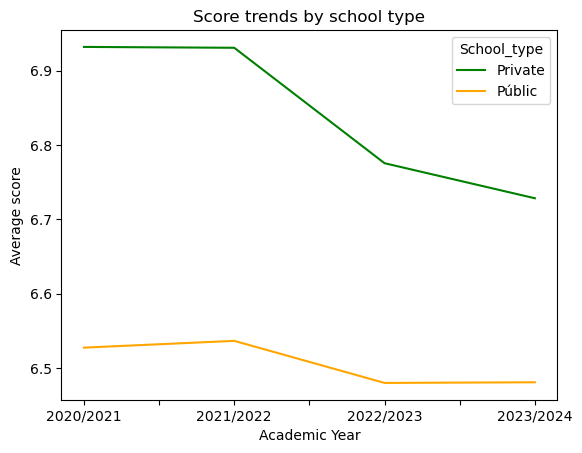

In [193]:
h3.plot(
    color=(["green", "orange"])
)
plt.title("Score trends by school type")
plt.xlabel("Academic Year")
plt.ylabel("Average score")

In [137]:
df1.head()

,Region,School_type,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021
0,Alt Pirineu i Aran,Públic,6.353000,6.274429,6.584000,6.649429
1,Baix Llobregat,Private,6.904682,6.818136,6.852273,6.961909
2,Baix Llobregat,Públic,6.523275,6.466627,6.574333,6.562549
3,Barcelonès,Private,6.553278,6.728316,6.708053,6.779632
4,Barcelonès,Públic,6.018105,6.103459,6.016943,6.125556


Both private and public schools show an downward trend in average university entrance exam scores over the 4 years. 
But the decrease appears larger for private schools.  

- Does the region with higher quantity of students enroled have higher scores? 

(Relationship between students quantity and performance? (due to hight competivity etc.))

In [138]:
# Determine the region with most students

In [139]:
df_enrol.head()

,Region,School_type,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021
0,Alt Pirineu i Aran,Private,459.0,459.0,419.0,437.0
1,Alt Pirineu i Aran,Públic,3122.0,3105.0,3018.0,3001.0
2,Baix Llobregat,Private,13245.0,13245.0,13106.0,13066.0
3,Baix Llobregat,Públic,34671.0,34873.0,34497.0,34449.0
4,Barcelonès,Private,64347.0,64347.0,63546.0,64883.0


In [140]:
h4 = df_enrol.groupby(["Region", "School_type"])[[
    "Enrolment 2023/2024", 
    "Enrolment 2022/2023", 
    "Enrolment 2021/2022", 
    "Enrolment 2020/2021"
 ]].mean()

In [141]:
h4["Overview"] = h4.mean(axis=1)
h4.sort_values("Overview", ascending=False).reset_index()

,Region,School_type,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021,Overview
0,Barcelonès,Private,64347.0,64347.0,63546.0,64883.0,64280.75
1,Barcelonès,Públic,51843.0,51383.0,50083.0,49275.0,50646.00
2,Vallès Occidental,Públic,39264.0,39093.0,39115.0,38791.0,39065.75
3,Maresme - Vallès Oriental,Públic,38876.0,38930.0,38102.0,37609.0,38379.25
4,Girona,Públic,36744.0,36373.0,35493.0,35003.0,35903.25
5,Baix Llobregat,Públic,34671.0,34873.0,34497.0,34449.0,34622.50
6,Tarragona,Públic,25208.0,25169.0,24359.0,24031.0,24691.75
7,Catalunya Central,Públic,24344.0,23756.0,23218.0,22868.0,23546.50
8,Vallès Occidental,Private,20661.0,20661.0,20747.0,20811.0,20720.00
9,Penedès,Públic,18177.0,18175.0,16848.0,17645.0,17711.25


The region with most student enrolment is Barcelonès private (mean of 11.5705 students), followed by the same region's public schools (mean of 9.1162 students). While the region with the lowest enrol rates is Alt Pirinei i Aran private schools (mean = 789 students) and Terres de l'Ebre (mean = 2.007 students)

In [142]:
h5 = df1.groupby(["Region", "School_type"])[[ "Average_grade_2023/2024", "Average_grade_2022/2023", "Average_grade_2021/2022", "Average_grade_2020/2021" ]].mean()


In [143]:
h5["Overview"] = h5.mean(axis=1)
h5.sort_values("Overview", ascending=False)

,,Average_grade_2023/2024,Average_grade_2022/2023,Average_grade_2021/2022,Average_grade_2020/2021,Overview
Region,School_type,,,,,
Maresme - Vallès Oriental,Private,6.737850,6.974050,7.128550,7.143500,6.995988
Penedès,Private,6.703333,6.758667,7.183667,7.078556,6.931056
Girona,Private,6.764692,6.845308,6.991538,7.047667,6.912301
Tarragona,Private,6.850143,6.782462,7.095385,6.829538,6.889382
Baix Llobregat,Private,6.904682,6.818136,6.852273,6.961909,6.884250
Vallès Occidental,Private,6.802929,6.909714,6.931929,6.876393,6.880241
Catalunya Central,Private,6.770778,6.860556,6.746444,7.125750,6.875882
Lleida,Private,6.802091,6.806182,7.016818,6.826091,6.862795
Consorci d'Educació de Barcelona,Private,6.756570,6.764851,6.845242,6.833064,6.799932


The region with the highest average score over 4 years is Maresme - Vallès Oriental private schools (11th position in enrolment rates out of 21). While the region with the lowest average score is Barcelonès public schools. Suggests low competitivity? 

Enrolment rates is not a strong predictor of performance in terms of scores. 

In [144]:
# RANKING 
# Barcelonès private 
# Barcelonès public 
# Alt Pirineu i Aran private 
# Terres de l'Ebre 

- Enrolment by school type

In [145]:
h6 = df_enrol.groupby("School_type")[[
    "Enrolment 2023/2024", 
    "Enrolment 2022/2023", 
    "Enrolment 2021/2022", 
    "Enrolment 2020/2021"
 ]].mean()
h6

,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021
School_type,,,,
Private,13607.363636,13607.363636,13466.363636,13570.000000
Públic,27011.272727,26846.909091,26224.636364,25983.727273


In [146]:
h6["Overview"] = h6.mean(axis=1)
h6 = h6.sort_values("Overview", ascending=False).round(2)
h6

,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021,Overview
School_type,,,,,
Públic,27011.27,26846.91,26224.64,25983.73,26516.64
Private,13607.36,13607.36,13466.36,13570.00,13562.77


In [147]:
df_enrol["Enrolment 2023/2024"].dtype

dtype('float64')

In [148]:
rate = h6["Overview"][1]/h6["Overview"][0]

C:\Users\mocim\AppData\Local\Temp\ipykernel_20548\2135044301.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rate = h6["Overview"][1]/h6["Overview"][0]


In [149]:
rate = ((h6["Overview"].iloc[1]/h6["Overview"].iloc[0])*100).round(2)
rate 

np.float64(51.15)

Public schools enrolment is much higher than private schools, about a 51.2% 

- Trend in enrolments over 4 years by school type

In [150]:
h6.columns

Index(['Enrolment 2023/2024', 'Enrolment 2022/2023', 'Enrolment 2021/2022',
       'Enrolment 2020/2021', 'Overview'],
      dtype='object')

In [151]:
h6 = h6[['Enrolment 2023/2024', 'Enrolment 2022/2023', 'Enrolment 2021/2022', 'Enrolment 2020/2021']]
h6

,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021
School_type,,,,
Públic,27011.27,26846.91,26224.64,25983.73
Private,13607.36,13607.36,13466.36,13570.00


In [152]:
h6_trans = h6.T
h6_trans

School_type,Públic,Private
Enrolment 2023/2024,27011.27,13607.36
Enrolment 2022/2023,26846.91,13607.36
Enrolment 2021/2022,26224.64,13466.36
Enrolment 2020/2021,25983.73,13570.00


In [190]:
h6_trans = h6_trans[::-1]
h6_trans 

School_type,Públic,Private
2020/2021,25983.73,13570.00
2021/2022,26224.64,13466.36
2022/2023,26846.91,13607.36
2023/2024,27011.27,13607.36


In [188]:
h6_trans.index = h6_trans.index.str.replace("Enrolment ","", regex=False)

<Axes: >

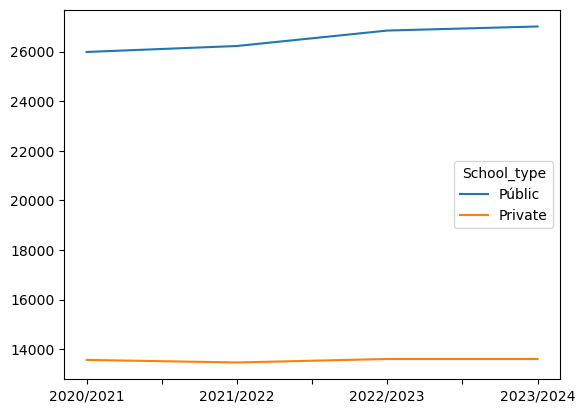

In [192]:
h6_trans.plot()

<Axes: xlabel='School_type'>

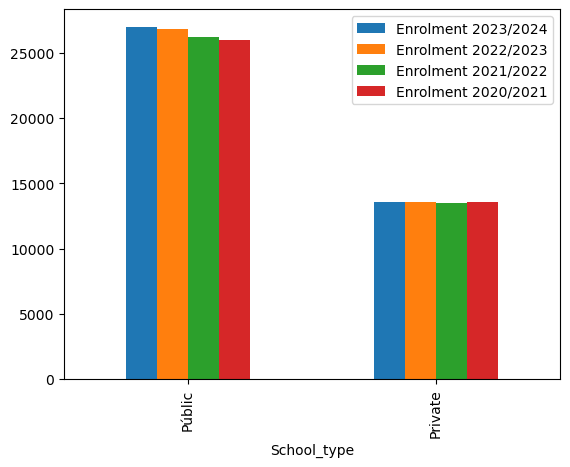

In [155]:
h6.plot(kind="bar")

- Proportion of enrolment by school type 

In [158]:
h6 = df_enrol.groupby("School_type")[[
    "Enrolment 2023/2024", 
    "Enrolment 2022/2023", 
    "Enrolment 2021/2022", 
    "Enrolment 2020/2021"
 ]].mean()

In [159]:
h6["Overview"] = h6.mean(axis=1)
h6 = h6.sort_values("Overview", ascending=False).round(2)
h6

,Enrolment 2023/2024,Enrolment 2022/2023,Enrolment 2021/2022,Enrolment 2020/2021,Overview
School_type,,,,,
Públic,27011.27,26846.91,26224.64,25983.73,26516.64
Private,13607.36,13607.36,13466.36,13570.00,13562.77


In [160]:
h6 = h6[["Overview"]]
h6

,Overview
School_type,
Públic,26516.64
Private,13562.77


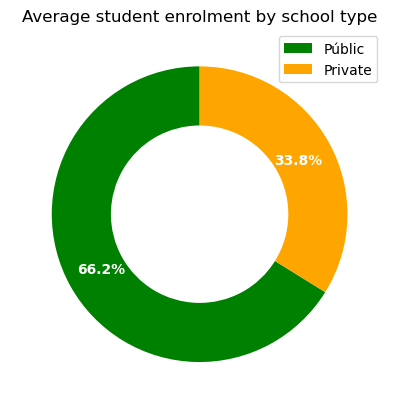

In [181]:
h6.plot(
    kind="pie", 
    y="Overview",
    autopct= "%1.1f%%", 
    startangle=90, 
    wedgeprops={"width":0.4},
    colors=["green", "orange"], 
    pctdistance=0.76, 
    textprops={"fontsize": 10, "fontweight": "bold", "color": "white"},
    
)

plt.ylabel("")
plt.title("Average student enrolment by school type")
plt.show()